# Spectral and Entropy Diagnostics (N4)

This notebook combines spectral predictability and entropy-based complexity diagnostics.

It covers:
- spectral predictability score (Omega),
- permutation/spectral entropy and complexity bands,
- optional largest Lyapunov exponent (LLE) with an explicit experimental warning.

In [1]:
%matplotlib inline
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from forecastability.datasets import generate_ar1, generate_henon_map, generate_white_noise
from forecastability.services.complexity_band_service import (
    _HIGH_THRESHOLD,
    _LOW_THRESHOLD,
    build_complexity_band,
)
from forecastability.services.lyapunov_service import build_largest_lyapunov_exponent
from forecastability.services.spectral_predictability_service import build_spectral_predictability

os.environ.setdefault("MPLBACKEND", "inline")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("Environment ready")

Environment ready


In [2]:
n = 512
t = np.arange(n, dtype=float)
seasonal = np.sin(2.0 * np.pi * t / 12.0) + 0.45 * np.sin(2.0 * np.pi * t / 6.0)

signals: dict[str, np.ndarray] = {
    "white_noise": generate_white_noise(n_samples=n, random_state=42),
    "ar1_phi_0_7": generate_ar1(n_samples=n, phi=0.7, random_state=3),
    "seasonal_mix": seasonal + np.random.default_rng(9).normal(0.0, 0.35, size=n),
    "henon_x": generate_henon_map(n_samples=n, discard=100),
}

for name, series in signals.items():
    print(f"{name}: n={series.size}")

white_noise: n=512
ar1_phi_0_7: n=512
seasonal_mix: n=512
henon_x: n=512


In [3]:
rows: list[dict[str, object]] = []
for name, series in signals.items():
    spectral = build_spectral_predictability(series)
    complexity = build_complexity_band(series)
    rows.append(
        {
            "signal": name,
            "omega": spectral.score,
            "spectral_entropy_norm": spectral.normalised_entropy,
            "permutation_entropy_norm": complexity.permutation_entropy,
            "complexity_band": complexity.complexity_band,
            "embedding_order": complexity.embedding_order,
            "pe_warning": complexity.pe_reliability_warning or "none",
        }
    )

diagnostics_df = pd.DataFrame(rows).sort_values("omega", ascending=False).reset_index(drop=True)
diagnostics_df

,signal,omega,spectral_entropy_norm,permutation_entropy_norm,complexity_band,embedding_order,pe_warning
0,seasonal_mix,0.513782,0.486218,0.887038,high,4,none
1,ar1_phi_0_7,0.175731,0.824269,0.967030,high,4,none
2,henon_x,0.105269,0.894731,0.679956,high,4,none
3,white_noise,0.037395,0.962605,0.992476,high,4,none


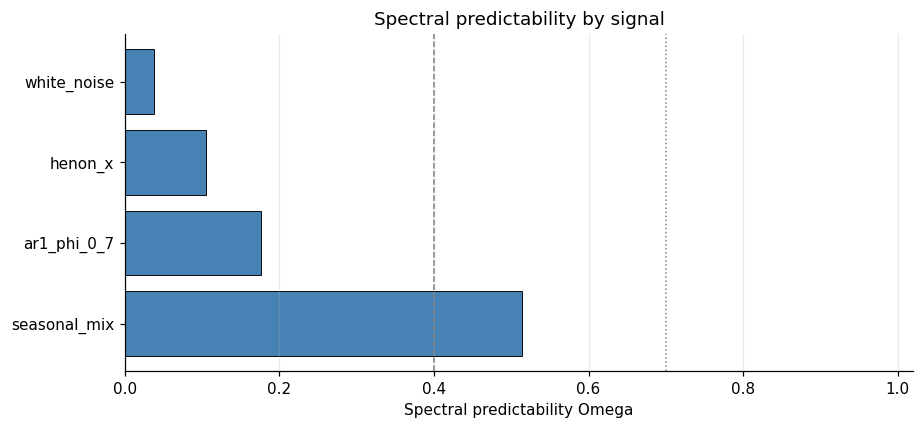

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.barh(
    diagnostics_df["signal"],
    diagnostics_df["omega"],
    color="steelblue",
    edgecolor="black",
    linewidth=0.6,
)
ax.axvline(0.40, color="gray", ls="--", lw=1.0)
ax.axvline(0.70, color="gray", ls=":", lw=1.0)
ax.set_xlim(0.0, 1.02)
ax.set_xlabel("Spectral predictability Omega")
ax.set_title("Spectral predictability by signal")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

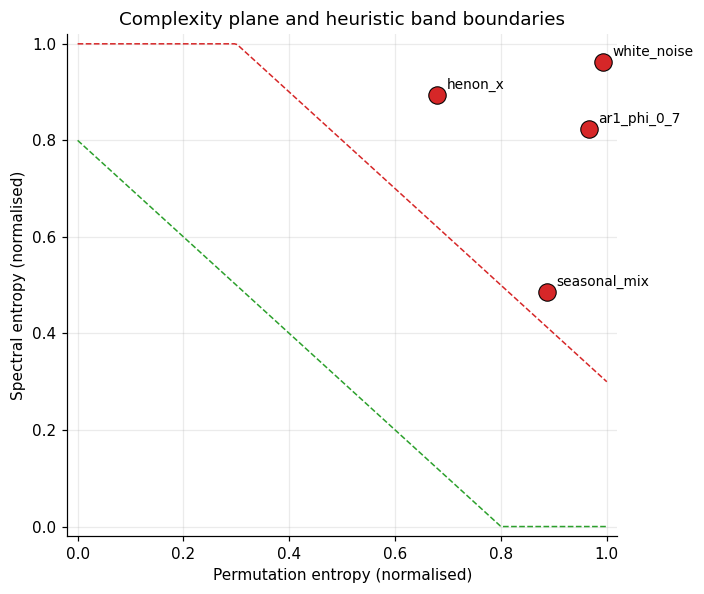

In [5]:
band_color = {"low": "#2ca02c", "medium": "#ff7f0e", "high": "#d62728"}

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for _, row in diagnostics_df.iterrows():
    ax.scatter(
        float(row["permutation_entropy_norm"]),
        float(row["spectral_entropy_norm"]),
        s=130,
        color=band_color[str(row["complexity_band"])],
        edgecolors="black",
        linewidths=0.7,
        zorder=3,
    )
    ax.annotate(
        str(row["signal"]),
        (float(row["permutation_entropy_norm"]), float(row["spectral_entropy_norm"])),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9,
    )

x = np.linspace(0.0, 1.0, 200)
ax.plot(x, np.clip(2.0 * _LOW_THRESHOLD - x, 0.0, 1.0), "--", color="#2ca02c", lw=1.0)
ax.plot(x, np.clip(2.0 * _HIGH_THRESHOLD - x, 0.0, 1.0), "--", color="#d62728", lw=1.0)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Permutation entropy (normalised)")
ax.set_ylabel("Spectral entropy (normalised)")
ax.set_title("Complexity plane and heuristic band boundaries")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Optional: Largest Lyapunov Exponent (Experimental)

LLE is included as an auxiliary diagnostic only. It is sensitive to embedding choices, finite-sample effects, and noise/non-stationarity.

Do not use this section as a standalone production decision rule.

In [6]:
lle_rows: list[dict[str, object]] = []
for name, series in signals.items():
    lle = build_largest_lyapunov_exponent(series, embedding_dim=3, delay=1)
    lle_rows.append(
        {
            "signal": name,
            "lambda_estimate": lle.lambda_estimate,
            "is_experimental": lle.is_experimental,
            "warning": lle.reliability_warning,
        }
    )

lle_df = (
    pd.DataFrame(lle_rows).sort_values("lambda_estimate", ascending=False).reset_index(drop=True)
)
lle_df

,signal,lambda_estimate,is_experimental,warning
0,henon_x,0.176799,True,EXPERIMENTAL — LLE unreliable: n=512 is below ...
1,ar1_phi_0_7,0.037339,True,EXPERIMENTAL — LLE unreliable: n=512 is below ...
2,white_noise,0.027970,True,EXPERIMENTAL — LLE unreliable: n=512 is below ...
3,seasonal_mix,0.021842,True,EXPERIMENTAL — LLE unreliable: n=512 is below ...


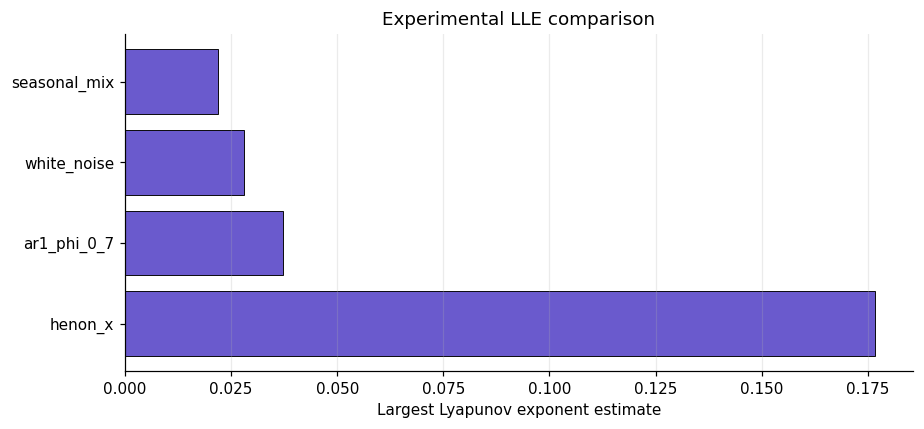

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.barh(
    lle_df["signal"], lle_df["lambda_estimate"], color="slateblue", edgecolor="black", linewidth=0.6
)
ax.axvline(0.0, color="black", ls="--", lw=1.0)
ax.set_xlabel("Largest Lyapunov exponent estimate")
ax.set_title("Experimental LLE comparison")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()